In [1]:
# ---- Cell 1: library import----
import numpy as np
import matplotlib.pyplot as plt
import scipy.sparse as sp
import h5py
from pathlib import Path

In [2]:
# ---- Cell 2: Select Path ----

hdf5_dir = Path("/scratch/yimili/matrices/hdf5")
name     = "carbon-nanotube"          # change per notebook
h5path   = hdf5_dir / f"{name}.h5"


In [3]:
# ---- Cell 3: load everything ----
def _load_sparse(g):
    shape = tuple(g.attrs["shape"]) if "shape" in g.attrs else None
    return sp.csc_matrix((g["data"][:], g["indices"][:], g["indptr"][:]), shape=shape)

with h5py.File(h5path, "r") as f:
    indices  = f["metadata/indices"][:].tolist()
    energies = f["metadata/energies"][:]
    
    H = (f["global/H"])[:]
    S = (f["global/S"])[:]
    
    max_singular_values = f["global/max_singular_values"][:]
    min_singular_values = f["global/min_singular_values"][:]
    kappa               = f["global/condition_full_svd"][:]

    M   = {idx: _load_sparse(f[f"E_{idx}/M"])     for idx in indices}
    Sig = {idx: _load_sparse(f[f"E_{idx}/Sigma"]) for idx in indices}
    rhs = {idx: f[f"E_{idx}/rhs"][:]              for idx in indices}
    w   = {idx: f[f"E_{idx}/spectrum"][:]         for idx in indices}

idx_arr = np.array(indices)
M_arr_sp = np.array([M[idx] for idx in idx_arr])

print(name, "| n_energies =", len(indices), "| E[-1] =", energies[-1])
print(idx_arr)
print(H.shape, H.dtype)

carbon-nanotube | n_energies = 402 | E[-1] = -2.5999999999999996
[  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179
 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197
 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215
 216 217 218 219 220 221 222 223 224 225 226 227 228 229 23

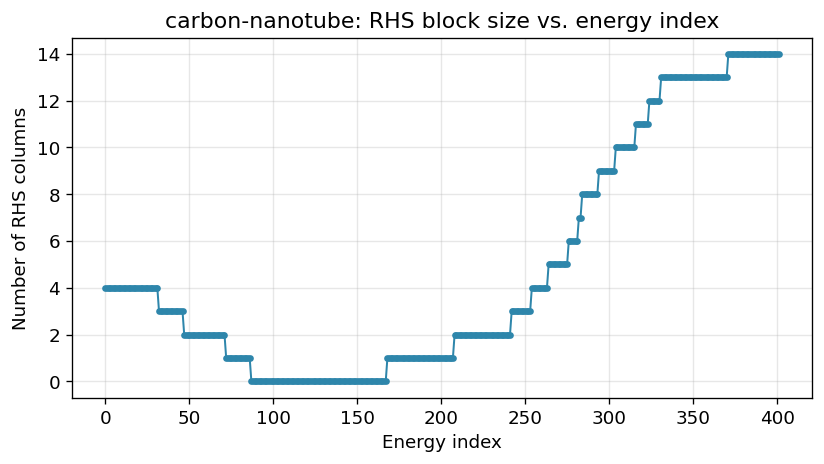

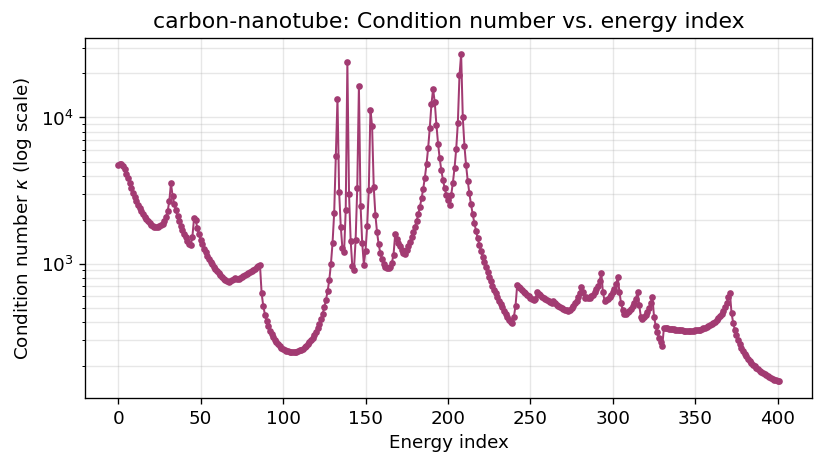

In [4]:
# ---- Cell 4: Plot data ----
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.dpi": 120,
    "font.size": 11,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

# ---------- Plot rhs size ----------
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(idx_arr, [rhs[idx].shape[-1] for idx in idx_arr],
        marker="o", markersize=3, linewidth=1.2, color="#2E86AB")
ax.set_xlabel("Energy index")
ax.set_ylabel("Number of RHS columns")
ax.set_title(f"{name}: RHS block size vs. energy index")
fig.tight_layout()
# fig.savefig("rhs_shape.png", dpi=150, bbox_inches="tight")
plt.show()

# ---------- Plot condition number (log scale) ----------
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(idx_arr, [kappa[idx] for idx in idx_arr],
        marker="o", markersize=3, linewidth=1.2, color="#A23B72")
ax.set_yscale("log")
ax.set_xlabel("Energy index")
ax.set_ylabel(r"Condition number $\kappa$ (log scale)")
ax.set_title(f"{name}: Condition number vs. energy index")
ax.grid(True, which="both", alpha=0.3)
fig.tight_layout()
# fig.savefig("kappa.png", dpi=150, bbox_inches="tight")
plt.show()

In [5]:

# =============================================================================
# ---- Cell 5: import solvers (replaces the old class definitions) ----
# =============================================================================
import sys
from pathlib import Path
sys.path.append(str((Path.cwd() / ".." / "solvers").resolve()))
 
from solver_classes import gpu_available   # everything else comes via bench_all
from bench_all import bench, DEFAULT_SOLVERS
print("GPU available:", gpu_available())
 


GPU available: False


In [6]:

# =============================================================================
# ---- Cell 6: configure experiment and run bench ----
# ---- results are appended directly into h5path (the material's own file), ----
# ---- nested as E_<idx>/solvers/<solver>/<dtype> -- no separate _LU.h5 ----
# =============================================================================
import numpy as np
import h5py
 
material = name                               # same file/material as Cell 2
dtypes   = (np.complex128, np.complex64)      # first entry = baseline dtype
bs       = 32                                 # block size (n must be divisible by it)
sweep    = list(range(0, 10))
EXCLUDE  = {"gmres": {"complex64"}}           # skip GMRES (SciPy) at single precision
# -------------------------------------------------------
# NOTE: this appends "solvers/..." groups into h5path itself, mutating the
# original material file in place. Take a filesystem-level backup of h5path
# before a big sweep if you'd rather not touch the source data directly.
 
print(f"{material} | dtypes={[np.dtype(d).name for d in dtypes]} | "
      f"baseline=SuperLU {np.dtype(dtypes[0]).name}")
print(f"appending solver results into: {h5path}\n")
 
metrics = []
with h5py.File(h5path, "a") as f:
    for idx in sweep:
        if rhs[idx].shape[-1] == 0:
            continue
        m = bench(M_arr_sp[idx], rhs[idx], idx, bs,
                  dtypes=dtypes, h5file=f, save=True, exclude=EXCLUDE)
        metrics.append(m)
 


carbon-nanotube | dtypes=['complex128', 'complex64'] | baseline=SuperLU complex128
appending solver results into: /scratch/yimili/matrices/hdf5/carbon-nanotube.h5

idx=0  n=768  B.shape=(768, 4)  nnz=12.15% of dense  baseline=superlu_c128
  superlu c128        : factor    10.38 ms  solve    0.710 ms  res 2.3e-15  mem     2.3 MB
  umfpack c128        : factor    10.48 ms  solve   13.953 ms  res 9.4e-16  mem     1.5 MB  vs base 5.9e-15
  mumps c128          : factor   177.46 ms  solve    0.896 ms  res 5.3e-15  mem     0.0 MB  (no L/U exposed)  vs base 1.2e-14
  gmres (scipy) c128  : factor     9.87 ms  solve    9.191 ms  res 2.0e-11  mem     2.0 MB  (it~3)  vs base 1.4e-11
  gmres (cupy) c128   : skipped (no GPU / CuPy not installed)
  cudss c128          : skipped (no GPU)
  block Thomas c128   : factor     4.51 ms  solve    1.607 ms  res 1.9e-15  mem     1.1 MB  vs base 6.9e-15
  superlu c64         : factor     6.53 ms  solve    0.566 ms  res 1.2e-06  mem     1.4 MB  vs base 3.6e-06
 

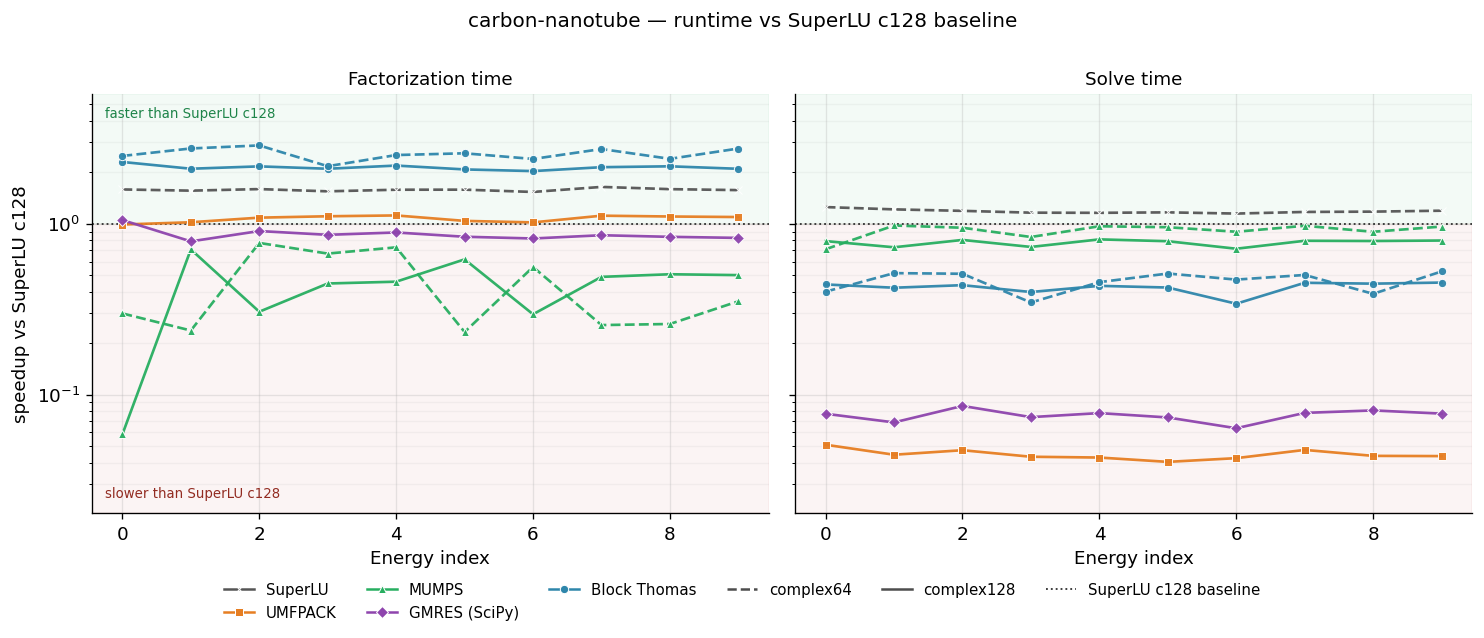

In [7]:

# =============================================================================
# ---- Cell 7: runtime comparison, all solvers x all dtypes vs SuperLU c128 ----
# =============================================================================
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
 
PRIMARY = "c128"                       # baseline = superlu at this dtype
DTYPE_LS = {"c128": "-", "c64": "--"}  # linestyle per precision
 
# solver base name -> (legend label, color, marker)
STYLE = {
    "superlu":      ("SuperLU",       "#555555", "x"),
    "umfpack":      ("UMFPACK",       "#E67E22", "s"),
    "mumps":        ("MUMPS",         "#27AE60", "^"),
    "gmres":        ("GMRES (SciPy)", "#8E44AD", "D"),
    "gmres_cupy":   ("GMRES (CuPy)",  "#C0392B", "v"),
    "cudss":        ("cuDSS",         "#16A085", "P"),
    "block_thomas": ("Block Thomas",  "#2E86AB", "o"),
}
 
 
def _speedup_series(solver, sfx, field):
    """(indices, baseline_time / solver_time) where this solver+dtype ran."""
    key, base_key = f"{solver}_{sfx}", f"superlu_{PRIMARY}"
    pts = [(m["idx"], m[base_key][field] / m[key][field])
           for m in metrics
           if key in m and base_key in m and m[key][field] > 0]
    if not pts:
        return [], []
    xs, ys = zip(*pts)
    return list(xs), list(ys)
 
 
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8), sharex=True, sharey=True)
solved_indices = [m["idx"] for m in metrics]
skipped = np.array(sorted(set(sweep) - set(solved_indices)))
 
# y-limits from the data itself (the shading must not drive autoscale)
all_speedups = [y for field in ("factor", "solve") for solver in STYLE
                for sfx in DTYPE_LS for y in _speedup_series(solver, sfx, field)[1]]
ymin = min(all_speedups + [1.0]) / 2.0
ymax = max(all_speedups + [1.0]) * 2.0
 
plotted_solvers, plotted_dtypes = [], []
for ax, field, panel in zip(axes, ["factor", "solve"],
                            ["Factorization time", "Solve time"]):
    for solver, (label, color, marker) in STYLE.items():
        for sfx, ls in DTYPE_LS.items():
            if solver == "superlu" and sfx == PRIMARY:
                continue                       # identically 1 -- it IS the baseline
            xs, ys = _speedup_series(solver, sfx, field)
            if not xs:
                continue
            ax.plot(xs, ys, color=color, marker=marker, ls=ls,
                    markersize=5, markeredgecolor="white", markeredgewidth=0.6,
                    lw=1.6, alpha=0.95, zorder=3)
            if solver not in plotted_solvers:
                plotted_solvers.append(solver)
            if sfx not in plotted_dtypes:
                plotted_dtypes.append(sfx)
 
    # baseline + faster/slower context shading (kept inside ylim)
    ax.axhline(1.0, color="0.2", lw=1.1, ls=":", zorder=2)
    ax.axhspan(1.0, ymax, color="#27AE60", alpha=0.05, zorder=0)
    ax.axhspan(ymin, 1.0, color="#C0392B", alpha=0.05, zorder=0)
 
    # shade index ranges that had no RHS columns
    if len(skipped):
        breaks = np.where(np.diff(skipped) > 1)[0] + 1
        for run in np.split(skipped, breaks):
            ax.axvspan(run[0] - 0.5, run[-1] + 0.5, color="0.55", alpha=0.25,
                       zorder=1)
 
    ax.set_yscale("log")
    ax.set_ylim(ymin, ymax)
    ax.set_xlabel("Energy index")
    ax.set_title(panel, fontsize=11)
    ax.grid(True, which="major", alpha=0.3)
    ax.grid(True, which="minor", alpha=0.12)
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
 
axes[0].set_ylabel(f"speedup vs SuperLU {PRIMARY}")
axes[0].text(0.02, 0.97, f"faster than SuperLU {PRIMARY}",
             transform=axes[0].transAxes, fontsize=8, color="#1E8449", va="top")
axes[0].text(0.02, 0.03, f"slower than SuperLU {PRIMARY}",
             transform=axes[0].transAxes, fontsize=8, color="#922B21", va="bottom")
 
# legend: one entry per solver (color+marker) + one per dtype (linestyle)
handles = [Line2D([], [], color=STYLE[s][1], marker=STYLE[s][2], ls="-",
                  markersize=5, markeredgecolor="white", markeredgewidth=0.6)
           for s in plotted_solvers]
labels = [STYLE[s][0] for s in plotted_solvers]
for sfx in plotted_dtypes:
    handles.append(Line2D([], [], color="0.3", ls=DTYPE_LS[sfx]))
    labels.append({"c128": "complex128", "c64": "complex64"}.get(sfx, sfx))
handles.append(Line2D([], [], color="0.2", lw=1.1, ls=":"))
labels.append(f"SuperLU {PRIMARY} baseline")
if len(skipped):
    handles.append(plt.Rectangle((0, 0), 1, 1, color="0.55", alpha=0.25))
    labels.append("no RHS")
fig.legend(handles, labels, loc="lower center", ncol=min(len(labels), 6),
           frameon=False, fontsize=9, bbox_to_anchor=(0.5, -0.08))
 
fig.suptitle(f"{material} — runtime vs SuperLU {PRIMARY} baseline",
             fontsize=12, y=1.0)
fig.tight_layout()
# fig.savefig(f"speedup_{material}.png", dpi=150, bbox_inches="tight")
plt.show()
